# ⭐ Day 52: Logistic Regression
## Titanic Survival Prediction Tutorial | Complete Guide

*Day 52 of 369-day Python & AI Learning Path* 🚀


## Welcome Aboard! 🚢

Congratulations on reaching Day 52 of your Python & AI journey! Today marks a pivotal moment in your machine learning education—we're transitioning from **regression** (predicting continuous values) to **classification** (predicting discrete categories). 

Logistic Regression stands as one of the most fundamental and widely-used algorithms in the data science toolkit. Despite its name containing "regression," it's actually a classification algorithm! Don't let that confuse you—it's the gateway to understanding how machines make binary decisions.

In this comprehensive tutorial, we'll dive deep into the mathematical foundations, implement the algorithm from scratch using NumPy, and then apply it to one of the most iconic datasets in machine learning history: the **Titanic survival dataset**. By the end of this notebook, you'll not only understand *how* logistic regression works, but *why* it works, and how to wield it effectively in your own projects.

Whether you're a beginner looking to solidify your understanding or an intermediate practitioner wanting to bridge theory and practice, this notebook is designed to be your complete reference. Let's set sail! 🌊


## 📋 Table of Contents

1. [Introduction to Classification and Logistic Regression](#1.-introduction-to-classification-and-logistic-regression)
2. [Mathematical Foundation](#2.-mathematical-foundation)
3. [Implementing Logistic Regression from Scratch](#3.-implementing-logistic-regression-from-scratch)
4. [Using Scikit-Learn LogisticRegression](#4.-using-scikit-learn-logisticregression)
5. [Applying to Titanic Dataset](#5.-applying-to-titanic-dataset)
6. [Model Interpretation](#6.-model-interpretation)
7. [Probability Calibration and Decision Threshold Tuning](#7.-probability-calibration-and-decision-threshold-tuning)
8. [Comparison: From Scratch vs Scikit-Learn](#8.-comparison-from-scratch-vs-scikit-learn)
9. [Key Insights and Limitations](#9.-key-insights-and-limitations)
10. [🛠️ Hands-On Exercises](#-hands-on-exercises)
11. [Solutions](#solutions)


## 1. Introduction to Classification and Logistic Regression

### What is Classification? 📊

Classification is a supervised learning task where we predict **discrete class labels** rather than continuous values. The two main types are:

- **Binary Classification**: Two possible outcomes (Yes/No, Spam/Not Spam, Survived/Did Not Survive)
- **Multi-class Classification**: More than two categories (Dog/Cat/Bird, Low/Medium/High)

### Why Not Linear Regression? 🤔

You might wonder: "Why can't we just use linear regression for classification?" 

The answer lies in the nature of our target variable. In classification:
- Outputs are bounded (typically 0 or 1)
- We need probabilities that sum to 1
- Linear regression can predict values outside [0,1] range
- The relationship is non-linear (S-shaped curve)

### Enter Logistic Regression 💡

Logistic Regression solves these problems by:
1. Using the **sigmoid function** to squash outputs between 0 and 1
2. Interpreting outputs as **probabilities**
3. Using **log loss** instead of mean squared error
4. Creating a **decision boundary** that separates classes

It's fast, interpretable, and serves as the foundation for neural networks (where it's called the "activation function")!


## 2. Mathematical Foundation

Before we code, let's understand the beautiful mathematics behind logistic regression.

### The Sigmoid Function 🔢

The sigmoid (or logistic) function transforms any real-valued number into a value between 0 and 1:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Where $z = w^T x + b$ (weighted sum of inputs plus bias).

### Log Loss (Binary Cross Entropy) 📉

Instead of Mean Squared Error, we use log loss to penalize wrong predictions more heavily:

$$L(y, \hat{y}) = -\frac{1}{m} \sum_{i=1}^{m} [y^{(i)} \log(\hat{y}^{(i)}) + (1-y^{(i)}) \log(1-\hat{y}^{(i)})]$$

This loss function has nice mathematical properties that make optimization easier and more stable.

### Gradient Descent 🎯

We minimize the cost function using gradient descent:

$$w := w - \alpha \frac{\partial L}{\partial w}$$
$$b := b - \alpha \frac{\partial L}{\partial b}$$

Where the gradients are surprisingly similar to linear regression:
$$\frac{\partial L}{\partial w} = \frac{1}{m} X^T (\hat{y} - y)$$


In [12]:
# 📚 Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve)
import warnings
warnings.filterwarnings('ignore')

# Set style for beautiful plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")
print("📦 NumPy version:", np.__version__)
print("📦 Pandas version:", pd.__version__)


✅ Libraries imported successfully!
📦 NumPy version: 2.2.6
📦 Pandas version: 3.0.0


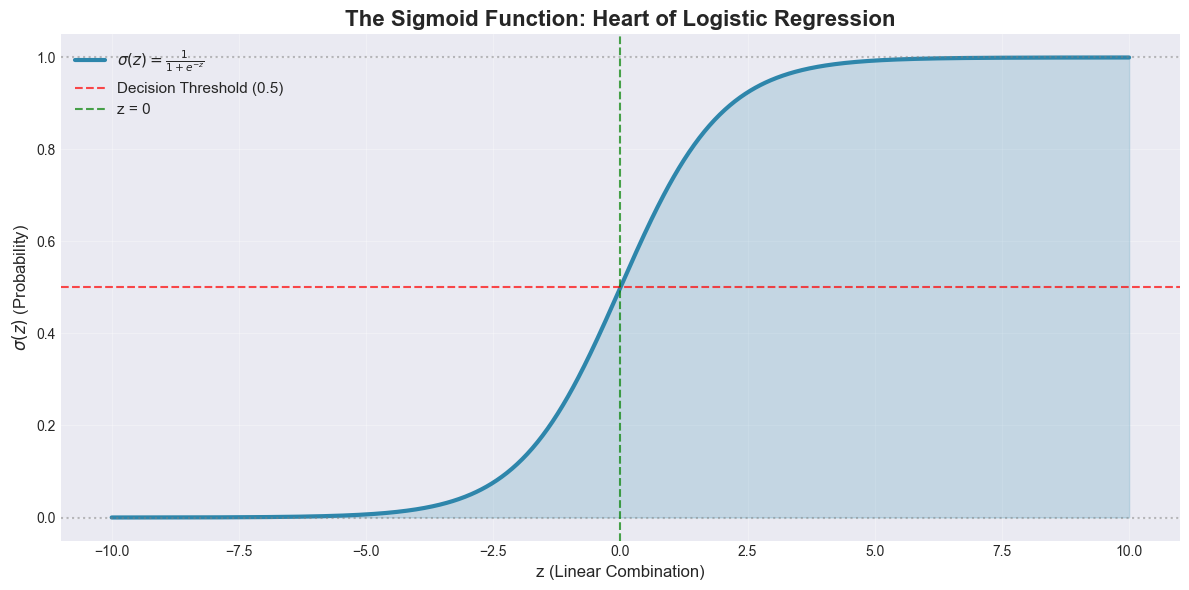

💡 Key Insight: As z → ∞, σ(z) → 1. As z → -∞, σ(z) → 0. At z = 0, σ(z) = 0.5


In [13]:
# 🔢 Visualizing the Sigmoid Function

def sigmoid(z):
    """
    Compute the sigmoid of z
    Args:
        z: scalar or array of any shape
    Returns:
        sigmoid(z) = 1 / (1 + exp(-z))
    """
    return 1 / (1 + np.exp(-z))

# Create range of values
z = np.linspace(-10, 10, 1000)
sigma_z = sigmoid(z)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(z, sigma_z, linewidth=3, label=r'$\sigma(z) = \frac{1}{1 + e^{-z}}$', color='#2E86AB')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Decision Threshold (0.5)')
plt.axhline(y=1, color='gray', linestyle=':', alpha=0.5)
plt.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
plt.axvline(x=0, color='green', linestyle='--', alpha=0.7, label='z = 0')
plt.fill_between(z, 0, sigma_z, alpha=0.2, color='#2E86AB')
plt.title('The Sigmoid Function: Heart of Logistic Regression', fontsize=16, fontweight='bold')
plt.xlabel('z (Linear Combination)', fontsize=12)
plt.ylabel(r'$\sigma(z)$ (Probability)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

print("💡 Key Insight: As z → ∞, σ(z) → 1. As z → -∞, σ(z) → 0. At z = 0, σ(z) = 0.5")


## 3. Implementing Logistic Regression from Scratch

Now comes the exciting part—building logistic regression from the ground up! This will give you deep intuition about how the algorithm works internally.


In [14]:
# 🏗️ Building Logistic Regression from Scratch

class LogisticRegressionScratch:
    """
    Logistic Regression implemented from scratch using NumPy.
    
    Parameters:
    -----------
    learning_rate : float, default=0.01
        The learning rate for gradient descent
    n_iterations : int, default=1000
        Maximum number of iterations for gradient descent
    verbose : bool, default=False
        Whether to print training progress
    """
    
    def __init__(self, learning_rate=0.01, n_iterations=1000, verbose=False):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.verbose = verbose
        self.weights = None
        self.bias = None
        self.cost_history = []
        
    def _sigmoid(self, z):
        """Sigmoid activation function"""
        # Clip values to prevent overflow
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def _compute_cost(self, y_true, y_pred):
        """
        Compute binary cross-entropy loss
        
        L = -1/m * Σ [y*log(ŷ) + (1-y)*log(1-ŷ)]
        """
        m = len(y_true)
        # Add small epsilon to prevent log(0)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        
        cost = -1/m * np.sum(y_true * np.log(y_pred) + 
                            (1 - y_true) * np.log(1 - y_pred))
        return cost
    
    def fit(self, X, y):
        """
        Train the model using gradient descent
        
        Parameters:
        -----------
        X : array-like, shape (m, n)
            Training features
        y : array-like, shape (m,)
            Target values (0 or 1)
        """
        # Initialize parameters
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0
        self.cost_history = []
        
        # Gradient descent
        for i in range(self.n_iterations):
            # Forward pass: compute predictions
            z = np.dot(X, self.weights) + self.bias
            y_pred = self._sigmoid(z)
            
            # Compute cost
            cost = self._compute_cost(y, y_pred)
            self.cost_history.append(cost)
            
            # Backward pass: compute gradients
            # dw = 1/m * X^T (y_pred - y)
            # db = 1/m * Σ (y_pred - y)
            dw = 1/m * np.dot(X.T, (y_pred - y))
            db = 1/m * np.sum(y_pred - y)
            
            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            if self.verbose and i % 100 == 0:
                print(f"Iteration {i}: Cost = {cost:.6f}")
        
        return self
    
    def predict_proba(self, X):
        """Predict probability estimates"""
        z = np.dot(X, self.weights) + self.bias
        return self._sigmoid(z)
    
    def predict(self, X, threshold=0.5):
        """Predict class labels"""
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)
    
    def score(self, X, y):
        """Calculate accuracy score"""
        predictions = self.predict(X)
        return np.mean(predictions == y)

print("✅ Custom Logistic Regression class created!")
print("🎯 Features implemented:")
print("   • Sigmoid activation")
print("   • Binary cross-entropy loss")
print("   • Gradient descent optimization")
print("   • Probability predictions")
print("   • Configurable decision threshold")


✅ Custom Logistic Regression class created!
🎯 Features implemented:
   • Sigmoid activation
   • Binary cross-entropy loss
   • Gradient descent optimization
   • Probability predictions
   • Configurable decision threshold


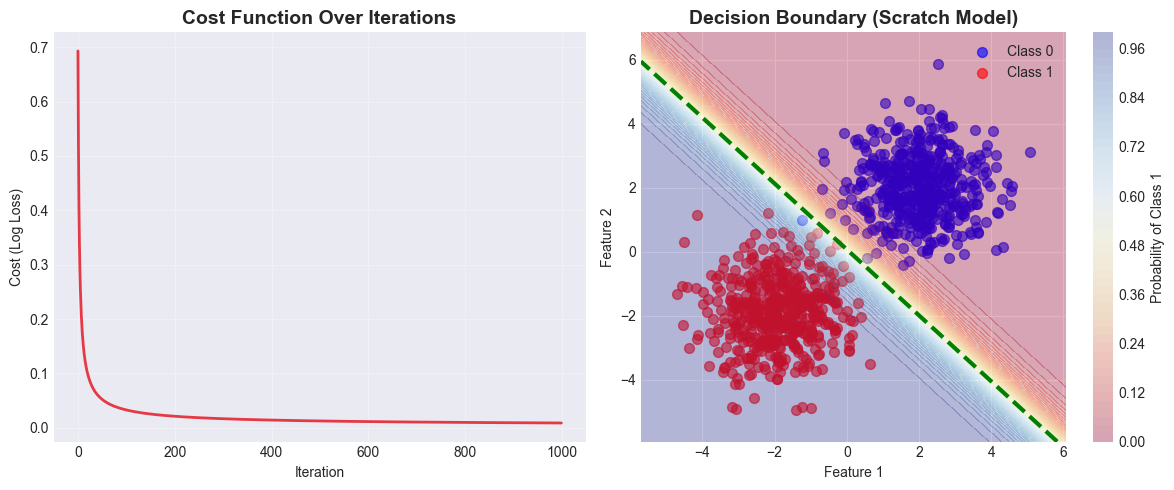

📊 Final Cost: 0.008975
🎯 Training Accuracy: 0.9990


In [15]:
# 🎨 Visualizing Cost Function Convergence

# Generate synthetic data for demonstration
np.random.seed(42)
m = 1000  # samples
n = 2     # features

# Create two classes
X_class0 = np.random.randn(m//2, n) + np.array([2, 2])
X_class1 = np.random.randn(m//2, n) + np.array([-2, -2])
X_synthetic = np.vstack([X_class0, X_class1])
y_synthetic = np.hstack([np.zeros(m//2), np.ones(m//2)])

# Shuffle
shuffle_idx = np.random.permutation(m)
X_synthetic = X_synthetic[shuffle_idx]
y_synthetic = y_synthetic[shuffle_idx]

# Train our model
model_scratch = LogisticRegressionScratch(learning_rate=0.1, n_iterations=1000, verbose=False)
model_scratch.fit(X_synthetic, y_synthetic)

# Plot cost history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(model_scratch.cost_history, linewidth=2, color='#E63946')
plt.title('Cost Function Over Iterations', fontsize=14, fontweight='bold')
plt.xlabel('Iteration')
plt.ylabel('Cost (Log Loss)')
plt.grid(True, alpha=0.3)

# Plot decision boundary
plt.subplot(1, 2, 2)
plt.scatter(X_synthetic[y_synthetic==0][:, 0], X_synthetic[y_synthetic==0][:, 1], 
           c='blue', label='Class 0', alpha=0.6, s=50)
plt.scatter(X_synthetic[y_synthetic==1][:, 0], X_synthetic[y_synthetic==1][:, 1], 
           c='red', label='Class 1', alpha=0.6, s=50)

# Plot decision boundary line
x_min, x_max = X_synthetic[:, 0].min() - 1, X_synthetic[:, 0].max() + 1
y_min, y_max = X_synthetic[:, 1].min() - 1, X_synthetic[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
Z = model_scratch.predict_proba(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contour(xx, yy, Z, levels=[0.5], colors='green', linewidths=3, linestyles='--')
plt.contourf(xx, yy, Z, levels=50, alpha=0.3, cmap='RdYlBu')

plt.title('Decision Boundary (Scratch Model)', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.colorbar(label='Probability of Class 1')
plt.tight_layout()
plt.show()

print(f"📊 Final Cost: {model_scratch.cost_history[-1]:.6f}")
print(f"🎯 Training Accuracy: {model_scratch.score(X_synthetic, y_synthetic):.4f}")


## 4. Using Scikit-Learn LogisticRegression

Now let's see how the professionals do it. Scikit-Learn provides a highly optimized, production-ready implementation.


In [16]:
# 🤖 Scikit-Learn Implementation

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_synthetic, y_synthetic, test_size=0.2, random_state=42, stratify=y_synthetic
)

# Scale features (important for gradient descent)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train scikit-learn model
model_sklearn = LogisticRegression(max_iter=1000, random_state=42)
model_sklearn.fit(X_train_scaled, y_train)

# Predictions
y_pred_sklearn = model_sklearn.predict(X_test_scaled)
y_prob_sklearn = model_sklearn.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("=" * 50)
print("📈 SCIKIT-LEARN MODEL PERFORMANCE")
print("=" * 50)
print(f"✅ Accuracy:  {accuracy_score(y_test, y_pred_sklearn):.4f}")
print(f"✅ Precision: {precision_score(y_test, y_pred_sklearn):.4f}")
print(f"✅ Recall:    {recall_score(y_test, y_pred_sklearn):.4f}")
print(f"✅ F1 Score:  {f1_score(y_test, y_pred_sklearn):.4f}")
print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred_sklearn, target_names=['Class 0', 'Class 1']))


📈 SCIKIT-LEARN MODEL PERFORMANCE
✅ Accuracy:  1.0000
✅ Precision: 1.0000
✅ Recall:    1.0000
✅ F1 Score:  1.0000

📋 Detailed Classification Report:
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00       100
     Class 1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



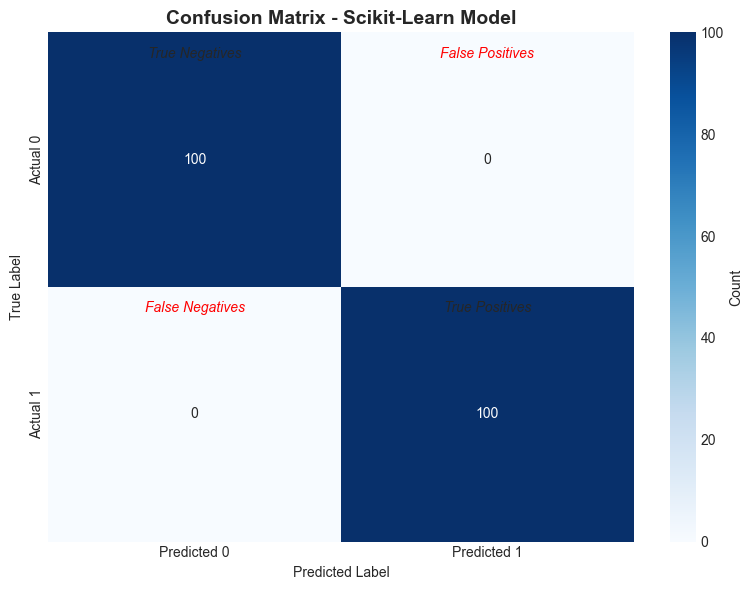

In [17]:
# 📊 Confusion Matrix Visualization

def plot_confusion_matrix(y_true, y_pred, title):
    """Plot a beautiful confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'],
                cbar_kws={'label': 'Count'})
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    # Add text annotations
    plt.text(0.5, 0.1, 'True Negatives', ha='center', fontsize=10, style='italic')
    plt.text(1.5, 0.1, 'False Positives', ha='center', fontsize=10, style='italic', color='red')
    plt.text(0.5, 1.1, 'False Negatives', ha='center', fontsize=10, style='italic', color='red')
    plt.text(1.5, 1.1, 'True Positives', ha='center', fontsize=10, style='italic')
    
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test, y_pred_sklearn, 'Confusion Matrix - Scikit-Learn Model')


## 5. Applying to Titanic Dataset 🚢

Now for the main event! We'll apply logistic regression to predict survival on the Titanic. This is a classic machine learning problem that tests your ability to handle real-world data challenges.


In [18]:
# 📥 Load and Explore Titanic Dataset

# Load the dataset (using seaborn's built-in dataset)
titanic = sns.load_dataset('titanic')

print("🚢 TITANIC DATASET OVERVIEW")
print("=" * 50)
print(f"📊 Shape: {titanic.shape[0]} rows × {titanic.shape[1]} columns")
print(f"\n📋 Columns:\n{titanic.columns.tolist()}")
print(f"\n🔍 First 5 rows:")
display(titanic.head())

print(f"\n📈 Survival Rate: {titanic['survived'].mean():.2%}")
print(f"🎯 Target Distribution:")
print(titanic['survived'].value_counts())


🚢 TITANIC DATASET OVERVIEW
📊 Shape: 891 rows × 15 columns

📋 Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

🔍 First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



📈 Survival Rate: 38.38%
🎯 Target Distribution:
survived
0    549
1    342
Name: count, dtype: int64


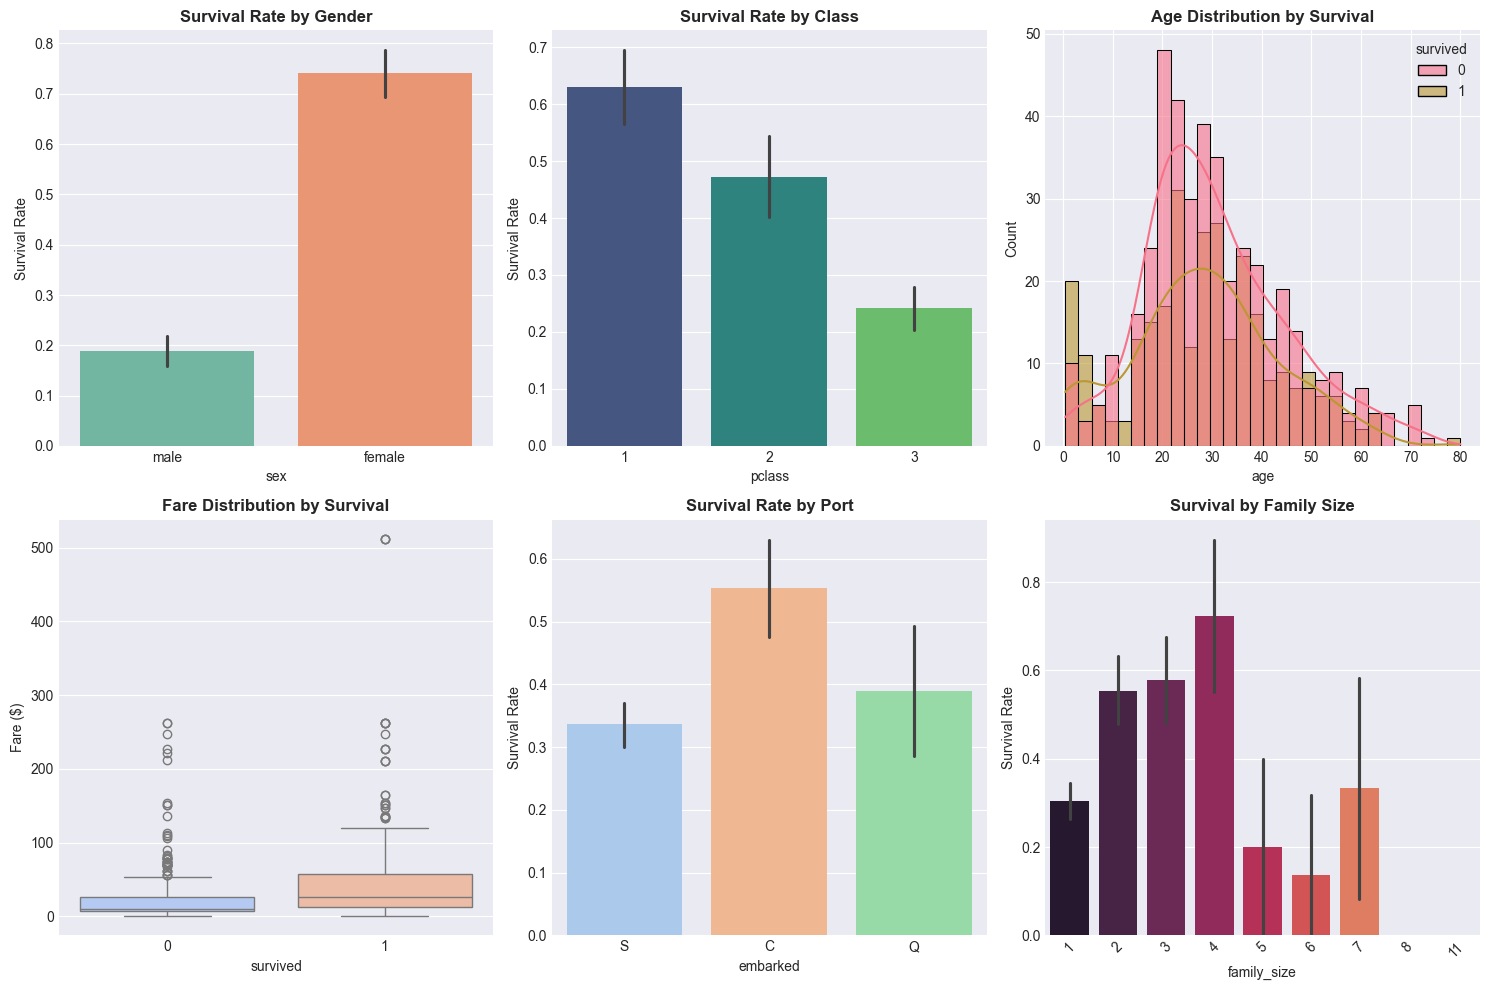

💡 Key Insights from EDA:
   • Women had much higher survival rates than men
   • 1st class passengers survived more than 3rd class
   • Higher fare correlates with survival
   • Small families (2-4 members) had better survival rates


In [19]:
# 🔍 Exploratory Data Analysis (Quick Overview)

plt.figure(figsize=(15, 10))

# Survival by Sex
plt.subplot(2, 3, 1)
sns.barplot(data=titanic, x='sex', y='survived', palette='Set2')
plt.title('Survival Rate by Gender', fontweight='bold')
plt.ylabel('Survival Rate')

# Survival by Pclass
plt.subplot(2, 3, 2)
sns.barplot(data=titanic, x='pclass', y='survived', palette='viridis')
plt.title('Survival Rate by Class', fontweight='bold')
plt.ylabel('Survival Rate')

# Age distribution
plt.subplot(2, 3, 3)
sns.histplot(data=titanic, x='age', hue='survived', bins=30, kde=True, alpha=0.6)
plt.title('Age Distribution by Survival', fontweight='bold')

# Fare distribution
plt.subplot(2, 3, 4)
sns.boxplot(data=titanic, x='survived', y='fare', palette='coolwarm')
plt.title('Fare Distribution by Survival', fontweight='bold')
plt.ylabel('Fare ($)')

# Embarked
plt.subplot(2, 3, 5)
sns.barplot(data=titanic, x='embarked', y='survived', palette='pastel')
plt.title('Survival Rate by Port', fontweight='bold')
plt.ylabel('Survival Rate')

# Family size
plt.subplot(2, 3, 6)
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1
sns.barplot(data=titanic, x='family_size', y='survived', palette='rocket')
plt.title('Survival by Family Size', fontweight='bold')
plt.ylabel('Survival Rate')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("💡 Key Insights from EDA:")
print("   • Women had much higher survival rates than men")
print("   • 1st class passengers survived more than 3rd class")
print("   • Higher fare correlates with survival")
print("   • Small families (2-4 members) had better survival rates")


In [20]:
# 🧹 Data Preprocessing Pipeline

def preprocess_titanic_data(df):
    """
    Comprehensive preprocessing for Titanic dataset
    """
    data = df.copy()
    
    # 1. Handle missing values
    # Fill Age with median by Sex and Pclass
    data['age'] = data.groupby(['sex', 'pclass'])['age'].transform(
        lambda x: x.fillna(x.median())
    )
    
    # Fill Embarked with mode
    data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0])
    
    # Fill Fare with median
    data['fare'] = data['fare'].fillna(data['fare'].median())
    
    # 2. Feature Engineering
    # Family size
    data['family_size'] = data['sibsp'] + data['parch'] + 1
    
    # Is alone
    data['is_alone'] = (data['family_size'] == 1).astype(int)
    
    # Title-style categorical feature
    if 'name' in data.columns:
        data['title'] = data['name'].str.extract(' ([A-Za-z]+)\.', expand=False)
        data['title'] = data['title'].replace(['Lady', 'Countess', 'Capt', 'Col', 
                                              'Don', 'Dr', 'Major', 'Rev', 'Sir', 
                                              'Jonkheer', 'Dona'], 'Rare')
        data['title'] = data['title'].replace('Mlle', 'Miss')
        data['title'] = data['title'].replace('Ms', 'Miss')
        data['title'] = data['title'].replace('Mme', 'Mrs')
        data['title'] = data['title'].fillna('Unknown')
    elif 'who' in data.columns:
        data['title'] = data['who'].fillna('Unknown')
    else:
        data['title'] = 'Unknown'
    
    # Age bins
    data['age_bin'] = pd.cut(data['age'], bins=[0, 12, 20, 40, 60, 100], 
                           labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'],
                           include_lowest=True)
    
    # Fare bins
    fare_rank = data['fare'].rank(method='first')
    data['fare_bin'] = pd.qcut(fare_rank, 4, labels=['Low', 'Med-Low', 'Med-High', 'High'])
    
    # 3. Encoding categorical variables
    # One-hot encoding
    categorical_cols = ['sex', 'embarked', 'title', 'age_bin', 'fare_bin']
    data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)
    
    # 4. Select features for modeling
    feature_cols = ['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 
                    'is_alone'] + [col for col in data.columns if col.startswith(
                    ('sex_', 'embarked_', 'title_', 'age_bin_', 'fare_bin_'))]
    
    return data[feature_cols], data['survived']

# Preprocess
X, y = preprocess_titanic_data(titanic)

print("✅ Preprocessing Complete!")
print(f"📊 Feature matrix shape: {X.shape}")
print(f"\n🔧 Selected Features:")
for i, col in enumerate(X.columns, 1):
    print(f"   {i:2d}. {col}")

print(f"\n📈 Missing values per feature:")
print(X.isnull().sum().sum(), "total missing values")


✅ Preprocessing Complete!
📊 Feature matrix shape: (891, 19)

🔧 Selected Features:
    1. pclass
    2. age
    3. sibsp
    4. parch
    5. fare
    6. family_size
    7. is_alone
    8. sex_male
    9. embarked_Q
   10. embarked_S
   11. title_man
   12. title_woman
   13. age_bin_Teen
   14. age_bin_Adult
   15. age_bin_Middle
   16. age_bin_Senior
   17. fare_bin_Med-Low
   18. fare_bin_Med-High
   19. fare_bin_High

📈 Missing values per feature:
0 total missing values


In [21]:
# 🏋️ Training the Titanic Model

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
titanic_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
titanic_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = titanic_model.predict(X_test_scaled)
y_prob = titanic_model.predict_proba(X_test_scaled)[:, 1]

print("🚢 TITANIC MODEL PERFORMANCE")
print("=" * 50)
print(f"✅ Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"✅ Precision: {precision_score(y_test, y_pred):.4f}")
print(f"✅ Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"✅ F1 Score:  {f1_score(y_test, y_pred):.4f}")

# ROC AUC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
print(f"✅ ROC-AUC:   {roc_auc:.4f}")


🚢 TITANIC MODEL PERFORMANCE
✅ Accuracy:  0.8436
✅ Precision: 0.8154
✅ Recall:    0.7681
✅ F1 Score:  0.7910
✅ ROC-AUC:   0.8565


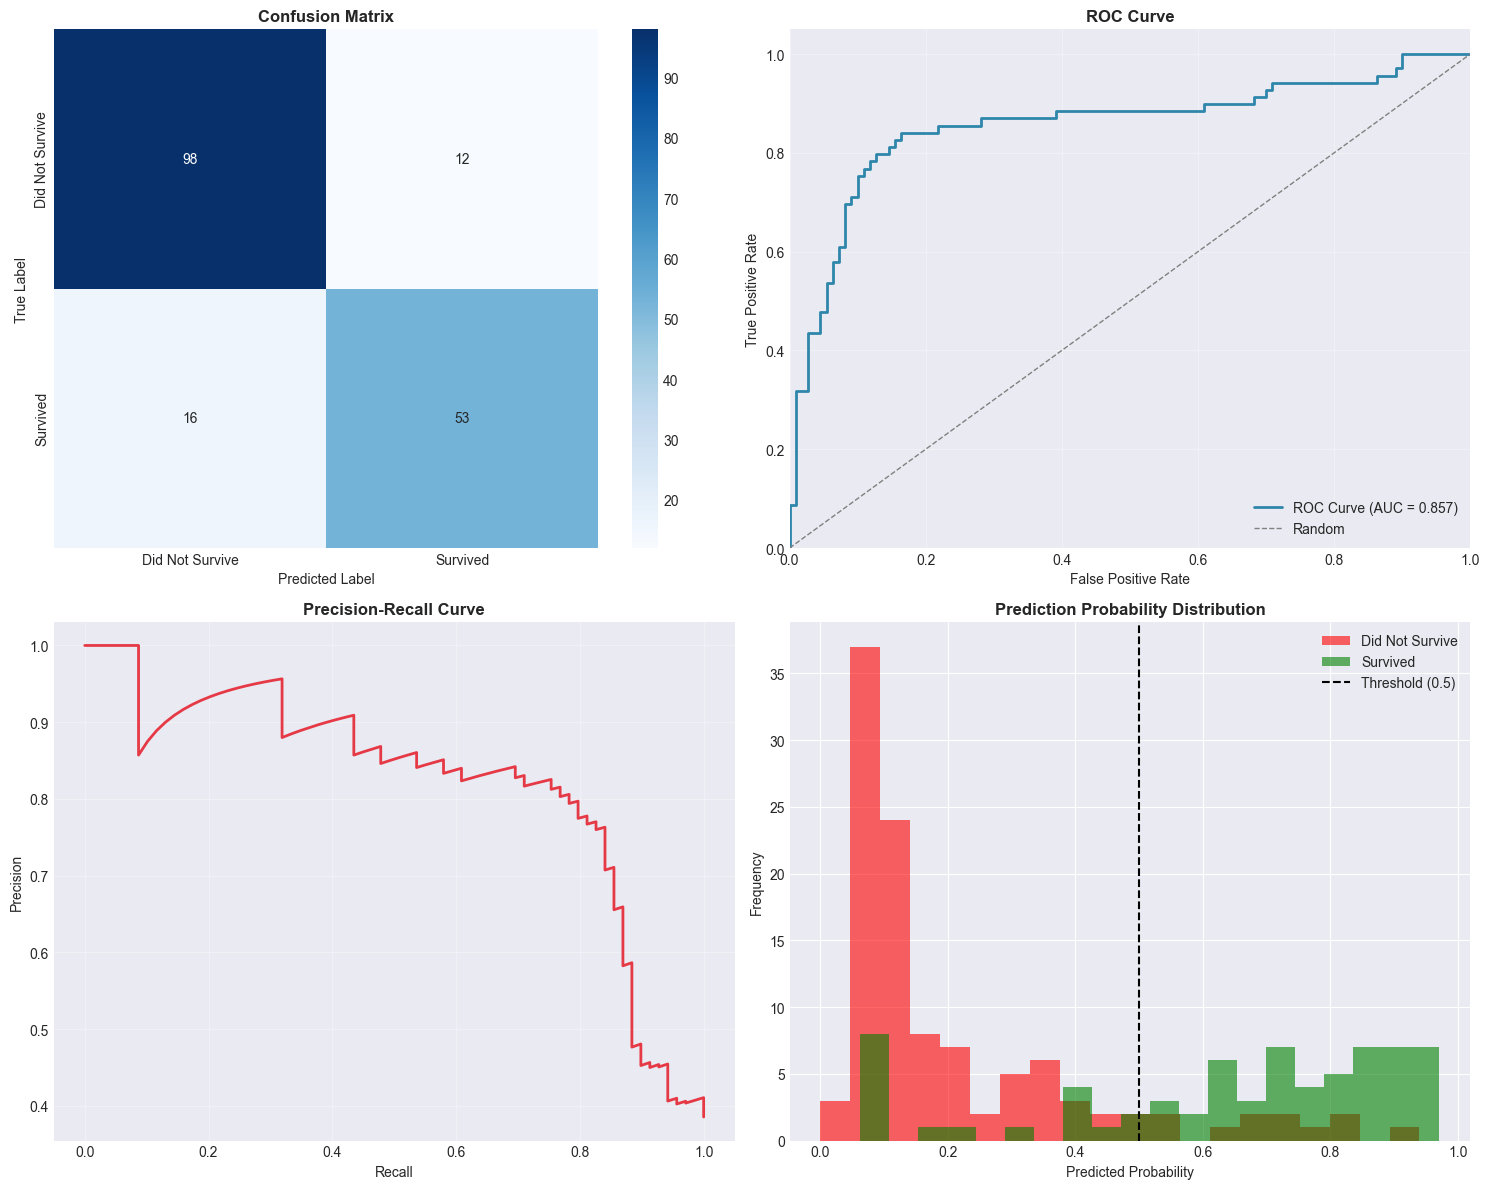

In [22]:
# 📊 Comprehensive Evaluation Visualizations

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])
axes[0,0].set_title('Confusion Matrix', fontweight='bold', fontsize=12)
axes[0,0].set_ylabel('True Label')
axes[0,0].set_xlabel('Predicted Label')

# 2. ROC Curve
axes[0,1].plot(fpr, tpr, color='#2E86AB', lw=2, 
               label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[0,1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
axes[0,1].set_xlim([0.0, 1.0])
axes[0,1].set_ylim([0.0, 1.05])
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve', fontweight='bold', fontsize=12)
axes[0,1].legend(loc='lower right')
axes[0,1].grid(True, alpha=0.3)

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
axes[1,0].plot(recall, precision, color='#E63946', lw=2)
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].set_title('Precision-Recall Curve', fontweight='bold', fontsize=12)
axes[1,0].grid(True, alpha=0.3)

# 4. Prediction Probability Distribution
axes[1,1].hist(y_prob[y_test==0], bins=20, alpha=0.6, label='Did Not Survive', color='red')
axes[1,1].hist(y_prob[y_test==1], bins=20, alpha=0.6, label='Survived', color='green')
axes[1,1].axvline(x=0.5, color='black', linestyle='--', label='Threshold (0.5)')
axes[1,1].set_xlabel('Predicted Probability')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Prediction Probability Distribution', fontweight='bold', fontsize=12)
axes[1,1].legend()

plt.tight_layout()
plt.show()


## 6. Model Interpretation 🔍

One of the greatest strengths of Logistic Regression is its interpretability. Let's examine what the model learned.


📊 TOP 10 MOST IMPORTANT FEATURES
Rank  Feature              Coef       Odds Ratio   Impact
----------------------------------------------------------------------
11    title_man            -1.0166    0.3618       🔴 Decreases Survival
1     pclass               -0.7282    0.4828       🔴 Decreases Survival
3     sibsp                -0.4414    0.6431       🔴 Decreases Survival
19    fare_bin_High        0.4233     1.5270       🟢 Increases Survival
2     age                  -0.3735    0.6883       🔴 Decreases Survival
6     family_size          -0.3691    0.6913       🔴 Decreases Survival
18    fare_bin_Med-High    0.3119     1.3660       🟢 Increases Survival
14    age_bin_Adult        -0.3100    0.7334       🔴 Decreases Survival
12    title_woman          0.2833     1.3275       🟢 Increases Survival
13    age_bin_Teen         -0.2229    0.8002       🔴 Decreases Survival


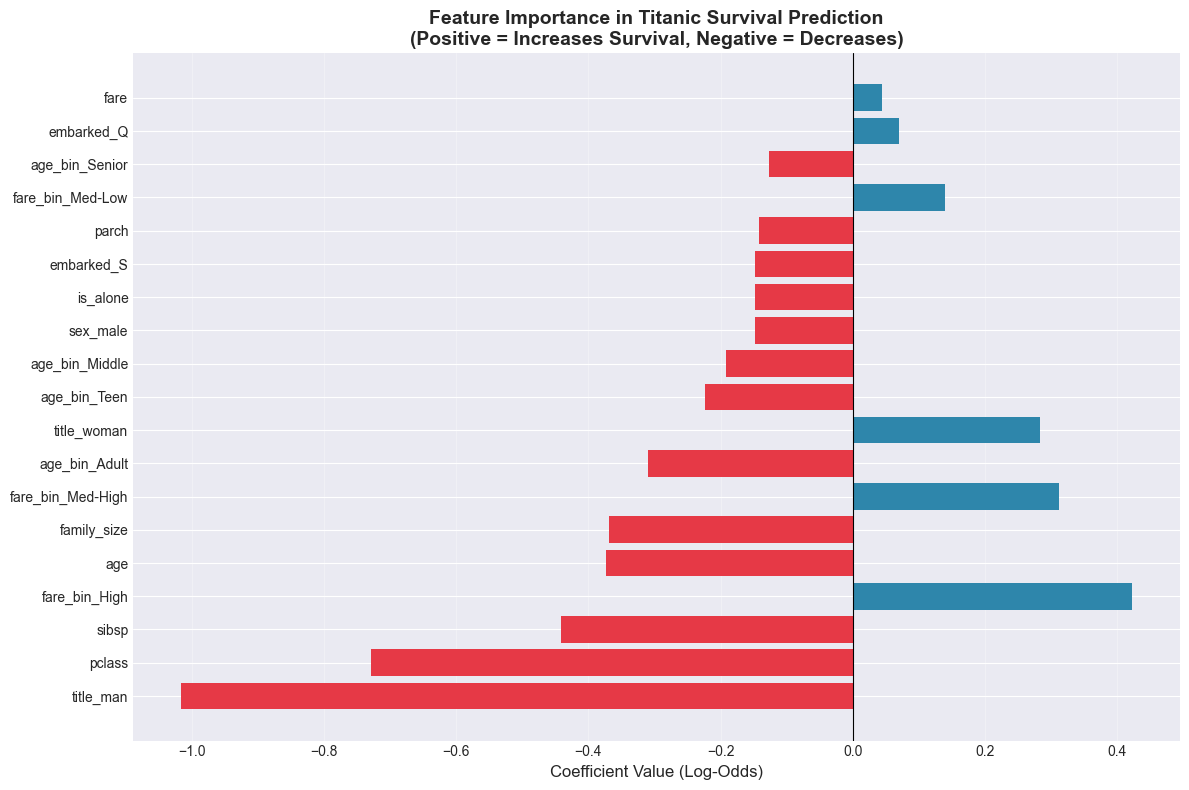


💡 Interpretation Guide:
   • Coefficient > 0: Feature increases log-odds of survival
   • Coefficient < 0: Feature decreases log-odds of survival
   • Odds Ratio > 1: Increases odds of survival
   • Odds Ratio < 1: Decreases odds of survival


In [23]:
# 🔍 Feature Importance Analysis

# Get coefficients
coefficients = titanic_model.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients),
    'Odds_Ratio': np.exp(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

print("📊 TOP 10 MOST IMPORTANT FEATURES")
print("=" * 70)
print(f"{'Rank':<5} {'Feature':<20} {'Coef':<10} {'Odds Ratio':<12} {'Impact'}")
print("-" * 70)

for idx, row in feature_importance.head(10).iterrows():
    impact = "🟢 Increases Survival" if row['Coefficient'] > 0 else "🔴 Decreases Survival"
    print(f"{idx+1:<5} {row['Feature']:<20} {row['Coefficient']:<10.4f} {row['Odds_Ratio']:<12.4f} {impact}")

# Visualization
plt.figure(figsize=(12, 8))
colors = ['#2E86AB' if c > 0 else '#E63946' for c in feature_importance['Coefficient']]
plt.barh(range(len(feature_importance)), feature_importance['Coefficient'], color=colors)
plt.yticks(range(len(feature_importance)), feature_importance['Feature'])
plt.xlabel('Coefficient Value (Log-Odds)', fontsize=12)
plt.title('Feature Importance in Titanic Survival Prediction\n(Positive = Increases Survival, Negative = Decreases)', 
          fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n💡 Interpretation Guide:")
print("   • Coefficient > 0: Feature increases log-odds of survival")
print("   • Coefficient < 0: Feature decreases log-odds of survival")
print("   • Odds Ratio > 1: Increases odds of survival")
print("   • Odds Ratio < 1: Decreases odds of survival")


## 7. Probability Calibration and Decision Threshold Tuning ⚖️

The default threshold of 0.5 might not be optimal for all scenarios. Let's explore how to tune it.


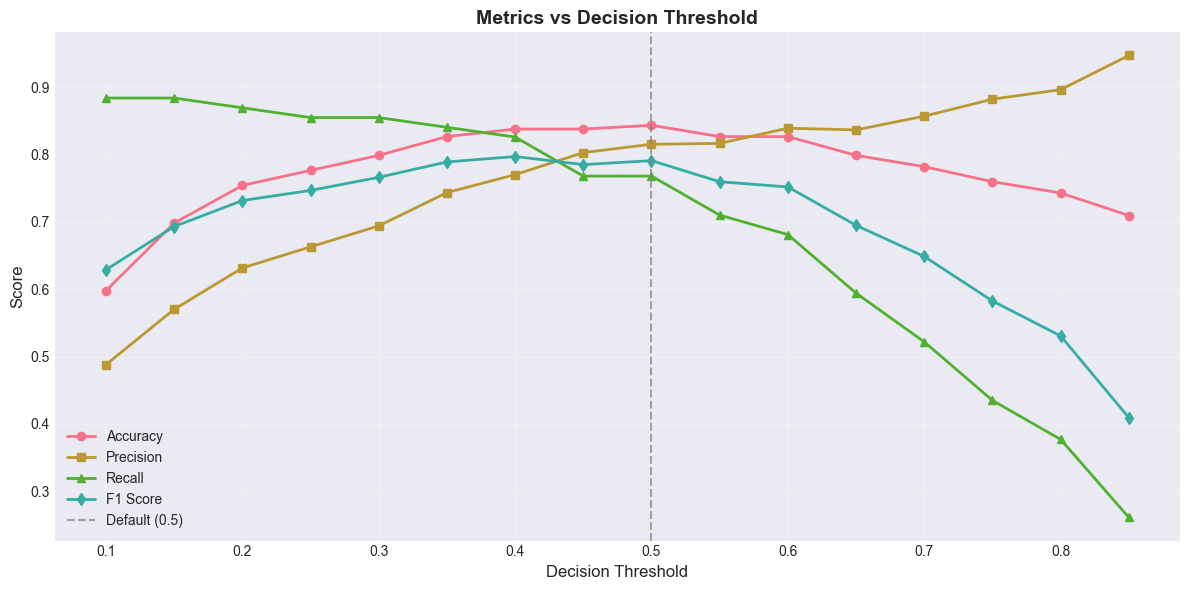

🎯 Optimal Threshold for F1 Score: 0.40
📈 F1 Score at optimal threshold: 0.7972


In [24]:
# ⚖️ Threshold Tuning Analysis

thresholds = np.arange(0.1, 0.9, 0.05)
metrics = {'threshold': [], 'accuracy': [], 'precision': [], 'recall': [], 'f1': []}

for thresh in thresholds:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    metrics['threshold'].append(thresh)
    metrics['accuracy'].append(accuracy_score(y_test, y_pred_thresh))
    metrics['precision'].append(precision_score(y_test, y_pred_thresh, zero_division=0))
    metrics['recall'].append(recall_score(y_test, y_pred_thresh, zero_division=0))
    metrics['f1'].append(f1_score(y_test, y_pred_thresh, zero_division=0))

metrics_df = pd.DataFrame(metrics)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(metrics_df['threshold'], metrics_df['accuracy'], 'o-', label='Accuracy', linewidth=2)
plt.plot(metrics_df['threshold'], metrics_df['precision'], 's-', label='Precision', linewidth=2)
plt.plot(metrics_df['threshold'], metrics_df['recall'], '^-', label='Recall', linewidth=2)
plt.plot(metrics_df['threshold'], metrics_df['f1'], 'd-', label='F1 Score', linewidth=2)
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Default (0.5)')
plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Metrics vs Decision Threshold', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find optimal threshold for F1
optimal_idx = metrics_df['f1'].idxmax()
optimal_threshold = metrics_df.loc[optimal_idx, 'threshold']
print(f"🎯 Optimal Threshold for F1 Score: {optimal_threshold:.2f}")
print(f"📈 F1 Score at optimal threshold: {metrics_df.loc[optimal_idx, 'f1']:.4f}")


## 8. Comparison: From Scratch vs Scikit-Learn ⚔️

Let's compare our custom implementation with the battle-tested Scikit-Learn version.


In [25]:
# ⚔️ Side-by-Side Comparison

# Prepare data for scratch model (needs scaling)
scratch_model = LogisticRegressionScratch(learning_rate=0.5, n_iterations=2000, verbose=False)
scratch_model.fit(X_train_scaled, y_train.values)

# Predictions
scratch_pred = scratch_model.predict(X_test_scaled)
scratch_prob = scratch_model.predict_proba(X_test_scaled)

# Comparison table
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
'From Scratch': [
        accuracy_score(y_test, scratch_pred),
        precision_score(y_test, scratch_pred),
        recall_score(y_test, scratch_pred),
        f1_score(y_test, scratch_pred)
    ],
    'Scikit-Learn': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})

comparison['Difference'] = comparison['From Scratch'] - comparison['Scikit-Learn']

print("⚔️ MODEL COMPARISON: From Scratch vs Scikit-Learn")
print("=" * 70)
print(comparison.to_string(index=False, float_format='%.4f'))

print("\n📊 Analysis:")
if abs(comparison['Difference']).max() < 0.05:
    print("   ✅ Excellent! Our scratch implementation performs similarly to Scikit-Learn!")
else:
    print("   ⚠️  Some differences observed - likely due to optimization differences")
    
print(f"\n🔢 Scratch Model Weights (first 5): {scratch_model.weights[:5]}")
print(f"🔢 Scikit-Learn Weights (first 5): {titanic_model.coef_[0][:5]}")


⚔️ MODEL COMPARISON: From Scratch vs Scikit-Learn
   Metric  From Scratch  Scikit-Learn  Difference
 Accuracy        0.8436        0.8436      0.0000
Precision        0.8154        0.8154      0.0000
   Recall        0.7681        0.7681      0.0000
 F1 Score        0.7910        0.7910      0.0000

📊 Analysis:
   ✅ Excellent! Our scratch implementation performs similarly to Scikit-Learn!

🔢 Scratch Model Weights (first 5): [-0.7298747  -0.35923726 -0.46726591 -0.14418884  0.03361416]
🔢 Scikit-Learn Weights (first 5): [-0.72823558 -0.37352823 -0.44141315 -0.14116899  0.04447944]


## 9. Key Insights and Limitations 💡

### Strengths of Logistic Regression ✅

1. **Highly Interpretable**: Coefficients directly tell us feature impact
2. **Fast Training**: Simple gradient descent converges quickly
3. **Probabilistic Output**: Provides confidence scores, not just predictions
4. **Well-Calibrated**: Probabilities often reflect true likelihood
5. **Regularization Built-in**: L1/L2 regularization prevent overfitting
6. **Baseline Model**: Excellent starting point for classification tasks

### Limitations ⚠️

1. **Linear Decision Boundary**: Can't capture complex non-linear relationships
2. **Feature Engineering Required**: Needs manual creation of interaction terms
3. **Sensitive to Outliers**: Extreme values can skew coefficients
4. **Assumes Independence**: Features should not be highly correlated
5. **Imbalanced Data**: Can be biased toward majority class

### When to Use 🎯

- Baseline model for any classification task
When interpretability is crucial (medical, financial, legal)
- Feature selection (L1 regularization)
- Probability estimation needs
- Linearly separable data

### When to Avoid 🚫

- Highly non-linear relationships
- Complex image/text data (use deep learning)
- When interaction effects are crucial and unknown


## 🛠️ Hands-On Exercises

Put your skills to the test! Complete these exercises to solidify your understanding.

### Exercise 1: Implement Sigmoid from Scratch
Write a function to compute the sigmoid activation without using any external libraries (pure Python).

### Exercise 2: Manual Log Loss Calculation
Given y_true = [1, 0, 1, 1, 0] and y_pred = [0.9, 0.1, 0.8, 0.7, 0.2], calculate the log loss manually.

### Exercise 3: Learning Rate Experimentation
Train the scratch model with learning rates [0.001, 0.01, 0.1, 1.0] and compare convergence speeds.

### Exercise 4: Feature Engineering Challenge
Create 3 new features for the Titanic dataset and measure if they improve model performance.

### Exercise 5: Full Pipeline Construction
Build a complete Scikit-Learn pipeline including preprocessing, scaling, and logistic regression.

### Exercise 6: Threshold Optimization
Find the optimal decision threshold that maximizes the F2 score (weights recall higher than precision).

### Exercise 7: Cross-Validation
Implement 5-fold cross-validation on the Titanic dataset and report mean accuracy ± standard deviation.

### Exercise 8: Model Interpretation
Pick 3 passengers from the test set and explain in plain English why the model predicted survival or not.

### Exercise 9: Baseline Comparison
Compare Logistic Regression against a simple baseline (e.g., predict majority class) and quantify the improvement.

### Exercise 10: Improvement Proposal
Suggest and implement at least 2 improvements to achieve >82% accuracy on the test set.


In [26]:
# Exercise 1: Your code here


In [27]:
# Exercise 2: Your code here


In [28]:
# Exercise 3: Your code here


In [29]:
# Exercise 4: Your code here


In [30]:
# Exercise 5: Your code here


In [31]:
# Exercise 6: Your code here


In [32]:
# Exercise 7: Your code here


In [33]:
# Exercise 8: Your code here


In [34]:
# Exercise 9: Your code here


In [35]:
# Exercise 10: Your code here


## Solutions (Review After Attempting)

Detailed solutions for the exercises above.

### Solution 1: Pure Python Sigmoid
```python
import math

def sigmoid_python(z):
    return 1 / (1 + math.exp(-z))

# Test
print(sigmoid_python(0))    # Should be 0.5
print(sigmoid_python(2))    # Should be ~0.88
print(sigmoid_python(-2))   # Should be ~0.12
```

### Solution 2: Manual Log Loss
```python
import numpy as np

y_true = np.array([1, 0, 1, 1, 0])
y_pred = np.array([0.9, 0.1, 0.8, 0.7, 0.2])

# Manual calculation
loss = 0
for yt, yp in zip(y_true, y_pred):
    loss += yt * np.log(yp) + (1 - yt) * np.log(1 - yp)

log_loss = -loss / len(y_true)
print(f"Log Loss: {log_loss:.4f}")  # Should be ~0.1643
```

### Solution 3: Learning Rate Comparison
```python
learning_rates = [0.001, 0.01, 0.1, 1.0]
results = {}

for lr in learning_rates:
    model = LogisticRegressionScratch(learning_rate=lr, n_iterations=1000)
    model.fit(X_train_scaled, y_train.values)
    results[lr] = model.cost_history

# Plot all curves
plt.figure(figsize=(10, 6))
for lr, history in results.items():
    plt.plot(history, label=f'LR={lr}')
plt.legend()
plt.title('Convergence Comparison')
plt.show()
```

### Solution 4: New Features
```python
# Feature 1: Deck from Cabin
titanic['deck'] = titanic['cabin'].str[0] if 'cabin' in titanic.columns else 'Unknown'

# Feature 2: Fare per person
titanic['fare_per_person'] = titanic['fare'] / (titanic['family_size'] + 1)

# Feature 3: Is child
titanic['is_child'] = (titanic['age'] < 16).astype(int)

# Retrain and compare accuracy
```

### Solution 5: Full Pipeline
```python
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

numeric_features = ['age', 'fare', 'family_size']
categorical_features = ['sex', 'embarked', 'pclass']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)
print(pipeline.score(X_test, y_test))
```

### Solution 6: F2 Score Optimization
```python
from sklearn.metrics import fbeta_score

thresholds = np.arange(0.1, 0.9, 0.01)
f2_scores = []

for thresh in thresholds:
    y_pred = (y_prob >= thresh).astype(int)
    f2 = fbeta_score(y_test, y_pred, beta=2)
    f2_scores.append(f2)

optimal_thresh = thresholds[np.argmax(f2_scores)]
print(f"Optimal threshold for F2: {optimal_thresh:.2f}")
```

### Solution 7: Cross-Validation
```python
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(titanic_model, X_train_scaled, y_train, cv=5)
print(f"CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
```

### Solution 8: Individual Predictions
```python
# Select 3 passengers
sample_indices = [0, 10, 20]
samples = X_test.iloc[sample_indices]

for idx, (i, row) in enumerate(samples.iterrows()):
    prob = titanic_model.predict_proba([X_test_scaled[i]])[0][1]
    actual = y_test.iloc[i]
    print(f"Passenger {i}: P(Survive)={prob:.3f}, Actual={actual}")
    print(f"  Key factors: Sex={row.get('sex_male', 0)}, Pclass={row['pclass']}, Age={row['age']:.1f}")
```

### Solution 9: Baseline Comparison
```python
from sklearn.dummy import DummyClassifier

# Majority class baseline
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_scaled, y_train)
dummy_pred = dummy.predict(X_test_scaled)

print(f"Baseline Accuracy: {accuracy_score(y_test, dummy_pred):.4f}")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Improvement: {accuracy_score(y_test, y_pred) - accuracy_score(y_test, dummy_pred):.4f}")
```

### Solution 10: Accuracy Improvements
```python
# Improvement 1: Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2']}
grid = GridSearchCV(LogisticRegression(max_iter=1000, solver='liblinear'), 
                    param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)
print(f"Best params: {grid.best_params_}")
print(f"Best CV score: {grid.best_score_:.4f}")

# Improvement 2: Ensemble with different feature sets
# Try polynomial features or interaction terms
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_model = LogisticRegression(max_iter=2000, C=0.1)
poly_model.fit(X_train_poly, y_train)
print(f"Polynomial Features Accuracy: {poly_model.score(X_test_poly, y_test):.4f}")
```
